<a href="https://colab.research.google.com/github/MoeTahech/real-fake-face-detection-thesis/blob/main/baseline_colab_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Real vs Fake Face Detection — Baseline (Deepfake Detection)
Fine-tunes a pretrained ResNet18 to classify a face image as **real** (photograph) or **fake** (GAN-generated).

**Before running:** In Colab, go to `Runtime > Change runtime type > T4 GPU` (or any available GPU), then run the cells in order, top to bottom.

### Step 1 — Confirm you have a GPU

In [ ]:
!nvidia-smi

Wed Jul 22 23:50:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Step 2 — Mount Google Drive (so your trained model is never lost)

This connects your Google Drive to this Colab session. From now on, whenever the
training script saves a checkpoint, it saves it directly into your Drive — not
onto Colab's temporary disk. That means even if Colab disconnects mid-training,
whatever was saved so far is already safe in your Drive.

Running this cell will ask you to log in to your Google account and grant access.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/thesis_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("Checkpoints will be saved to:", CHECKPOINT_DIR)

Mounted at /content/drive
Checkpoints will be saved to: /content/drive/MyDrive/thesis_checkpoints


### Step 3 — Get the dataset

We'll use the **140k Real and Fake Faces** dataset from Kaggle. You need a free Kaggle account and an API token:

1. Go to https://www.kaggle.com/settings/account
2. Scroll to "API" → click "Create New Token"

In [ ]:
import os

KAGGLE_API_TOKEN = os.getenv("KAGGLE_API_TOKEN")

if KAGGLE_API_TOKEN:
    print("Kaggle token found")
else:
    print("No Kaggle token found")

In [ ]:
!pip install -q kaggle

!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d data_raw
!find data_raw -maxdepth 3 -type d

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [03:42<00:00, 18.1MB/s]

data_raw
data_raw/real_vs_fake
data_raw/real_vs_fake/real-vs-fake
data_raw/real_vs_fake/real-vs-fake/valid
data_raw/real_vs_fake/real-vs-fake/train
data_raw/real_vs_fake/real-vs-fake/test


In [ ]:
!find data_raw/real_vs_fake/real-vs-fake/train -maxdepth 2 -type d

data_raw/real_vs_fake/real-vs-fake/train
data_raw/real_vs_fake/real-vs-fake/train/real
data_raw/real_vs_fake/real-vs-fake/train/fake


### Step 4 — Check / fix the folder structure

This dataset already ships as `train/real`, `train/fake`, `valid/real`, `valid/fake`
(and `test/...`). Our code expects `data/train/...` and `data/val/...`, so we just
symlink `valid` to `val`. If the printed folder tree above looks different, tell me
and I'll adjust this cell.

In [ ]:
import os

base = "data_raw/real_vs_fake/real-vs-fake"  # confirmed correct from your output
base_abs = os.path.abspath(base)  # <-- key fix: absolute path

os.makedirs("data", exist_ok=True)

val_name = "valid" if os.path.isdir(os.path.join(base, "valid")) else "val"

!ln -sfn "{base_abs}/train" data/train
!ln -sfn "{base_abs}/{val_name}" data/val

print("train/real:", len(os.listdir("data/train/real")))
print("train/fake:", len(os.listdir("data/train/fake")))
print("val/real:", len(os.listdir("data/val/real")))
print("val/fake:", len(os.listdir("data/val/fake")))

train/real: 50000
train/fake: 50000
val/real: 10000
val/fake: 10000


### Step 5 (optional but recommended first) — Use a small subset for a fast test run

Training on the full 140k images takes a while even on GPU. Run this once to make
a small subset (e.g. 2,000 train / 500 val images) so you can confirm the whole
pipeline works end-to-end in a few minutes before committing to a full run.
Skip this cell if you want to go straight to the full dataset.

In [ ]:
import os, random, shutil

def make_subset(src_split, dst_split, n_per_class):
    for cls in ["real", "fake"]:
        src_dir = f"data/{src_split}/{cls}"
        dst_dir = f"data_small/{dst_split}/{cls}"
        os.makedirs(dst_dir, exist_ok=True)
        files = os.listdir(src_dir)
        random.shuffle(files)
        for f in files[:n_per_class]:
            shutil.copy(os.path.join(src_dir, f), os.path.join(dst_dir, f))

make_subset("train", "train", 1000)
make_subset("val", "val", 250)
print("Small subset ready in ./data_small")

Small subset ready in ./data_small


### Step 6 — Write the training and prediction scripts to disk

This is the same code from the files you already have — written here directly so
the notebook is self-contained.

In [ ]:
%%writefile train.py
"""
Simple baseline: fine-tune a pretrained ResNet18 to classify
face images as real (0) or fake (1).

Usage:
    python train.py --data_dir ./data --epochs 5 --batch_size 32
"""
import argparse
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm


def get_dataloaders(data_dir, batch_size, img_size=224):
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                      std=[0.229, 0.224, 0.225])

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize,
    ])
    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        normalize,
    ])

    train_set = datasets.ImageFolder(f"{data_dir}/train", transform=train_transform)
    val_set = datasets.ImageFolder(f"{data_dir}/val", transform=val_transform)

    print("Class mapping:", train_set.class_to_idx)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader, train_set.class_to_idx


def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model


def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, labels in tqdm(loader, desc="train" if train else "val"):
            images, labels = images.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data_dir", type=str, default="./data")
    parser.add_argument("--epochs", type=int, default=5)
    parser.add_argument("--batch_size", type=int, default=32)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--checkpoint_dir", type=str, default=".",
                         help="Folder where best_model.pth is saved (point this at your Drive folder)")
    args = parser.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    train_loader, val_loader, class_to_idx = get_dataloaders(args.data_dir, args.batch_size)

    model = build_model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=args.lr)

    import os
    os.makedirs(args.checkpoint_dir, exist_ok=True)
    save_path = os.path.join(args.checkpoint_dir, "best_model.pth")

    best_val_acc = 0.0
    for epoch in range(args.epochs):
        print(f"\nEpoch {epoch + 1}/{args.epochs}")
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer, device, train=False)

        print(f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                "model_state": model.state_dict(),
                "class_to_idx": class_to_idx,
            }, save_path)
            print(f"Saved new best model to {save_path} (val_acc={val_acc:.4f})")

    print(f"\nDone. Best validation accuracy: {best_val_acc:.4f}")
    print(f"Final checkpoint is at: {save_path}")


if __name__ == "__main__":
    main()


Writing train.py


In [ ]:
%%writefile predict.py
"""
Run the trained model on a single image and print REAL or FAKE.

Usage:
    python predict.py --model best_model.pth --image path/to/face.jpg
"""
import argparse
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms, models
import torch.nn as nn


def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--model", type=str, default="best_model.pth")
    parser.add_argument("--image", type=str, required=True)
    args = parser.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    checkpoint = torch.load(args.model, map_location=device)
    class_to_idx = checkpoint["class_to_idx"]
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    model = build_model()
    model.load_state_dict(checkpoint["model_state"])
    model.to(device)
    model.eval()

    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                      std=[0.229, 0.224, 0.225])
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        normalize,
    ])

    image = Image.open(args.image).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1)[0]
        pred_idx = probs.argmax().item()

    label = idx_to_class[pred_idx].upper()
    confidence = probs[pred_idx].item() * 100

    print(f"Prediction: {label}  (confidence: {confidence:.1f}%)")


if __name__ == "__main__":
    main()


Writing predict.py


### Step 7 — Train

First run this on the **small subset** to confirm everything works (should take
a few minutes on GPU). Notice `--checkpoint_dir` points at the Drive folder we
created in Step 2 — every improved checkpoint is saved straight there, not onto
Colab's temporary disk.

In [ ]:
!python train.py --data_dir ./data_small --epochs 3 --batch_size 32 --checkpoint_dir "{CHECKPOINT_DIR}"

Using device: cuda
Class mapping: {'fake': 0, 'real': 1}
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 214MB/s]

Epoch 1/3
train: 100% 63/63 [00:08<00:00,  7.66it/s]
val: 100% 16/16 [00:02<00:00,  7.41it/s]
train_loss=0.6391 train_acc=0.6360 val_loss=0.5463 val_acc=0.7280
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model.pth (val_acc=0.7280)

Epoch 2/3
train: 100% 63/63 [00:05<00:00, 11.31it/s]
val: 100% 16/16 [00:01<00:00, 10.50it/s]
train_loss=0.5438 train_acc=0.7300 val_loss=0.5022 val_acc=0.7680
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model.pth (val_acc=0.7680)

Epoch 3/3
train: 100% 63/63 [00:07<00:00,  8.31it/s]
val: 100% 16/16 [00:01<00:00, 10.01it/s]
train_loss=0.5327 train_acc=0.7350 val_loss=0.4876 val_acc=0.7720
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model.pth (val_acc=0

If that finishes and prints increasing accuracy, you're good. Now run on the
**full dataset** (this is the run whose numbers you'll actually report). Even if
this disconnects partway through, whatever was the best checkpoint so far is
already sitting safely in your Drive folder.

In [ ]:
!python train.py --data_dir ./data --epochs 5 --batch_size 64 --checkpoint_dir "{CHECKPOINT_DIR}"

Using device: cuda
Class mapping: {'fake': 0, 'real': 1}

Epoch 1/5
train: 100% 1563/1563 [05:35<00:00,  4.66it/s]
val: 100% 313/313 [01:02<00:00,  5.01it/s]
train_loss=0.4701 train_acc=0.7768 val_loss=0.4322 val_acc=0.8013
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model.pth (val_acc=0.8013)

Epoch 2/5
train: 100% 1563/1563 [05:28<00:00,  4.75it/s]
val: 100% 313/313 [01:00<00:00,  5.21it/s]
train_loss=0.4368 train_acc=0.7989 val_loss=0.4528 val_acc=0.7853

Epoch 3/5
train: 100% 1563/1563 [05:07<00:00,  5.08it/s]
val: 100% 313/313 [00:59<00:00,  5.22it/s]
train_loss=0.4333 train_acc=0.8009 val_loss=0.4259 val_acc=0.8015
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model.pth (val_acc=0.8015)

Epoch 4/5
train: 100% 1563/1563 [05:03<00:00,  5.16it/s]
val: 100% 313/313 [01:01<00:00,  5.06it/s]
train_loss=0.4295 train_acc=0.8020 val_loss=0.4183 val_acc=0.8108
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model.pt

### Step 8 — Test the trained model on one image (your "application")

Note we now load the model **from Drive**, not from the local Colab disk — this
also means that if your session disconnects and you reconnect later, you can
re-run this cell straight away without retraining, as long as Step 2 (mounting
Drive) has been run.

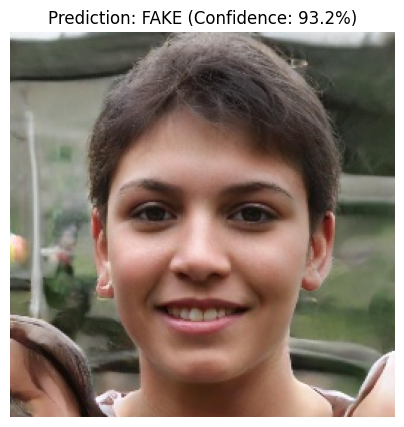

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Image path
img_path = "data_raw/real_vs_fake/real-vs-fake/test/fake/PXELOSPVJX.jpg"

# Load image
img = Image.open(img_path)

# Display
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")

# Add your prediction as title
plt.title("Prediction: FAKE (Confidence: 93.2%)")

plt.show()

In [ ]:
# pick any test image path, e.g. from the held-out test split
import os
sample_dir = f"{'data_raw/real_vs_fake/real-vs-fake'}/test/fake"
sample_img = os.path.join(sample_dir, os.listdir(sample_dir)[0])
print("Testing on:", sample_img)

model_path = f"{CHECKPOINT_DIR}/best_model.pth"
!python predict.py --model "{model_path}" --image "{sample_img}"

Testing on: data_raw/real_vs_fake/real-vs-fake/test/fake/PXELOSPVJX.jpg
Prediction: FAKE  (confidence: 93.2%)


### Step 9 — Proper evaluation on the full test set (for your report)

Accuracy on one image isn't a result — this cell runs the model over the whole
test split and gives you accuracy, AUC, and a confusion matrix, the numbers you
actually put in the thesis.

In [ ]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize,
])

test_dir = "data_raw/real_vs_fake/real-vs-fake/test"
test_set = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)
print("Class mapping:", test_set.class_to_idx)

checkpoint = torch.load(f"{CHECKPOINT_DIR}/best_model.pth", map_location=device)
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(checkpoint["model_state"])
model.to(device).eval()

all_labels, all_probs, all_preds = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]  # probability of class "1"
        preds = logits.argmax(dim=1)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test AUC: {auc:.4f}")
print("\nConfusion matrix:\n", confusion_matrix(all_labels, all_preds))
print("\n", classification_report(all_labels, all_preds, target_names=list(test_set.class_to_idx.keys())))

Class mapping: {'fake': 0, 'real': 1}
Test Accuracy: 0.8077
Test AUC: 0.8883

Confusion matrix:
 [[8050 1950]
 [1896 8104]]

               precision    recall  f1-score   support

        fake       0.81      0.81      0.81     10000
        real       0.81      0.81      0.81     10000

    accuracy                           0.81     20000
   macro avg       0.81      0.81      0.81     20000
weighted avg       0.81      0.81      0.81     20000



### Step 10 — Confirm your model is safe in Drive

Nothing to download manually — it was already saved to your Drive during training
(Step 7). This just double-checks the file is really there.

In [ ]:
import os
model_path = f"{CHECKPOINT_DIR}/best_model.pth"
if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"Found checkpoint at {model_path} ({size_mb:.1f} MB)")
    print("This file lives in your actual Google Drive, so it survives this Colab session ending.")
else:
    print("No checkpoint found yet — make sure Step 7 (training) completed at least one epoch.")

Found checkpoint at /content/drive/MyDrive/thesis_checkpoints/best_model.pth (42.7 MB)
This file lives in your actual Google Drive, so it survives this Colab session ending.


---
### What to save for your report
- The printed **class mapping** (which folder = 0 vs 1)
- Training/validation loss & accuracy per epoch (copy from the output, or screenshot)
- Final **test accuracy, AUC, confusion matrix** from Step 9 — these are your reportable numbers
- `best_model.pth` — already safe in `My Drive/thesis_checkpoints/`, no manual download needed

Next time you open Colab, you only need to: mount Drive (Step 2), re-run the
`%%writefile` cells (Step 6) if it's a fresh runtime, and then Step 8/9 load the
model straight from Drive — no retraining required unless you want to improve it.

Once you have these numbers, send them to me and I'll help you write the Methodology
and Results sections, and plan the next experiment (e.g. cross-dataset generalization test).